# Klasifikasi Dan BaggingClassifier Pada Dataset Ecoli

In [1]:
%pip install seaborn pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


## **1. Klasifikasi Ecoli ADASAYN Dan SMOTE Menggunakan Naive Bayes**

### **1.1 Klasifikasi Ecoli ADASYN (Naive Bayes)**

#### **1.1.1 Pengambilan Data**

In [2]:
# === KLASIFIKASI SMOTE MENGGUNAKAN NAIVE BAYES ===
import pandas as pd
from collections import Counter

print("\n" + "="*60)
print("KLASIFIKASI ADASYN MENGGUNAKAN NAIVE BAYES")
print("="*60)

# Load data dari CSV
df_original = pd.read_csv('data_ecoli_original.csv')
df_adasyn = pd.read_csv('data_ecoli_adasyn.csv')

X_orig = df_original[['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']]
y_orig = df_original['class']

X_adasyn = df_adasyn[['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']]
y_adasyn = df_adasyn    ['class']

print("Distribusi kelas data ORIGINAL (dari CSV):")
print(f"{sorted(Counter(y_orig).items())}")

print(f"\nDistribusi kelas data ADASYN (dari CSV):")
print(f"{sorted(Counter(y_adasyn).items())}")

print(f"\nTotal samples original: {len(y_orig)}")
print(f"Total samples ADASYN: {len(y_adasyn)}")
print(f"Data yang ditambahkan: {len(y_adasyn) - len(y_orig)}")



KLASIFIKASI ADASYN MENGGUNAKAN NAIVE BAYES
Distribusi kelas data ORIGINAL (dari CSV):
[('cp', 143), ('im', 77), ('imL', 2), ('imS', 2), ('imU', 35), ('om', 20), ('omL', 5), ('pp', 52)]

Distribusi kelas data ADASYN (dari CSV):
[('cp', 143), ('im', 151), ('imL', 142), ('imS', 142), ('imU', 144), ('om', 143), ('omL', 143), ('pp', 141)]

Total samples original: 336
Total samples ADASYN: 1149
Data yang ditambahkan: 813


#### **1.1.2 Klasifikasi Naive Bayes**

In [3]:
# === KLASIFIKASI MENGGUNAKAN NAIVE BAYES ===
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("\n" + "="*60)
print("KLASIFIKASI MENGGUNAKAN NAIVE BAYES")
print("="*60)

# 1. Klasifikasi data ORIGINAL
print("\n--- KLASIFIKASI DATA ORIGINAL ---")
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

nb_orig = GaussianNB()
nb_orig.fit(X_train_orig, y_train_orig)
y_pred_orig = nb_orig.predict(X_test_orig)

print(f"Accuracy data ORIGINAL: {accuracy_score(y_test_orig, y_pred_orig):.4f}")
print("\nClassification Report - ORIGINAL:")
print(classification_report(y_test_orig, y_pred_orig, zero_division=0))


KLASIFIKASI MENGGUNAKAN NAIVE BAYES

--- KLASIFIKASI DATA ORIGINAL ---
Accuracy data ORIGINAL: 0.7941

Classification Report - ORIGINAL:
              precision    recall  f1-score   support

          cp       0.97      1.00      0.98        29
          im       1.00      0.44      0.61        16
         imU       0.50      0.86      0.63         7
          om       0.00      0.00      0.00         4
         omL       1.00      1.00      1.00         1
          pp       0.61      1.00      0.76        11

    accuracy                           0.79        68
   macro avg       0.68      0.72      0.66        68
weighted avg       0.81      0.79      0.76        68



In [4]:
# 2. Klasifikasi data ADASYN
print("\n--- KLASIFIKASI DATA ADASYN ---")
X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42, stratify=y_adasyn
)

nb_adasyn = GaussianNB()
nb_adasyn.fit(X_train_adasyn, y_train_adasyn)
y_pred_adasyn = nb_adasyn.predict(X_test_adasyn)

print(f"Accuracy data ADASYN: {accuracy_score(y_test_adasyn, y_pred_adasyn):.4f}")
print("\nClassification Report - ADASYN:")
print(classification_report(y_test_adasyn, y_pred_adasyn, zero_division=0))


--- KLASIFIKASI DATA ADASYN ---
Accuracy data ADASYN: 0.8174

Classification Report - ADASYN:
              precision    recall  f1-score   support

          cp       0.88      1.00      0.94        29
          im       1.00      0.60      0.75        30
         imL       1.00      1.00      1.00        28
         imS       0.97      1.00      0.98        28
         imU       0.69      0.62      0.65        29
          om       1.00      0.48      0.65        29
         omL       1.00      1.00      1.00        29
          pp       0.45      0.86      0.59        28

    accuracy                           0.82       230
   macro avg       0.87      0.82      0.82       230
weighted avg       0.88      0.82      0.82       230




Confusion Matrix - ADASYN:
[[29  0  0  0  0  0  0  0]
 [ 0 18  0  0  8  0  0  4]
 [ 0  0 28  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0]
 [ 0  0  0  1 18  0  0 10]
 [ 0  0  0  0  0 14  0 15]
 [ 0  0  0  0  0  0 29  0]
 [ 4  0  0  0  0  0  0 24]]

Confusion Matrix - ORIGINAL:
[[29  0  0  0  0  0  0  0]
 [ 1  7  0  0  6  0  0  2]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  1]
 [ 0  0  0  0  0  0  0  4]
 [ 0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0 11]]


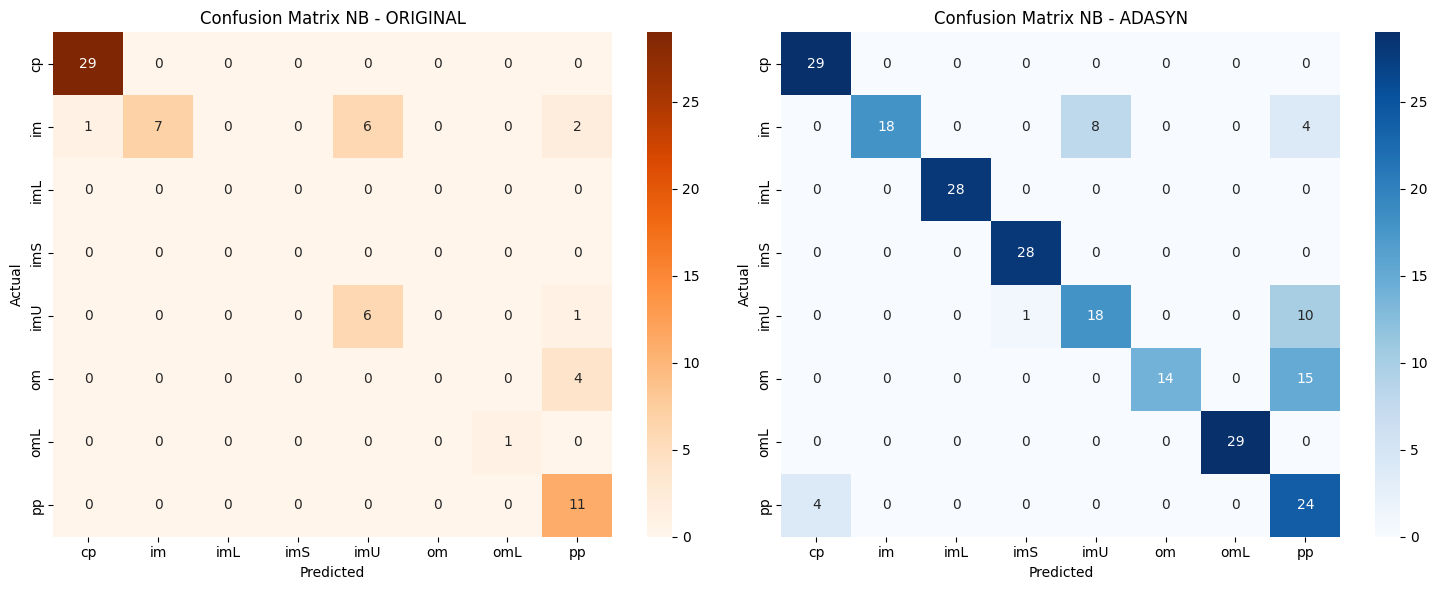

In [5]:
# Confusion Matrix - ADASYN
print("\nConfusion Matrix - ADASYN:")
cm_adasyn = confusion_matrix(y_test_adasyn, y_pred_adasyn)
print(cm_adasyn)

# Confusion Matrix - ORIGINAL
labels = sorted(y_orig.unique())
print("\nConfusion Matrix - ORIGINAL:")
cm_orig = confusion_matrix(y_test_orig, y_pred_orig, labels=labels)
print(cm_orig)

# Visualisasi Confusion Matrix
plt.figure(figsize=(15, 6))

# Plot Confusion Matrix ORIGINAL
plt.subplot(1, 2, 1)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Oranges', 
           xticklabels=labels, 
           yticklabels=labels)
plt.title('Confusion Matrix NB - ORIGINAL')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot Confusion Matrix ADASYN
plt.subplot(1, 2, 2)
sns.heatmap(cm_adasyn, annot=True, fmt='d', cmap='Blues',
           xticklabels=sorted(y_adasyn.unique()), 
           yticklabels=sorted(y_adasyn.unique()))
plt.title('Confusion Matrix NB - ADASYN')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

#### **1.1.3 Visualisasi Distribusi Kelas**

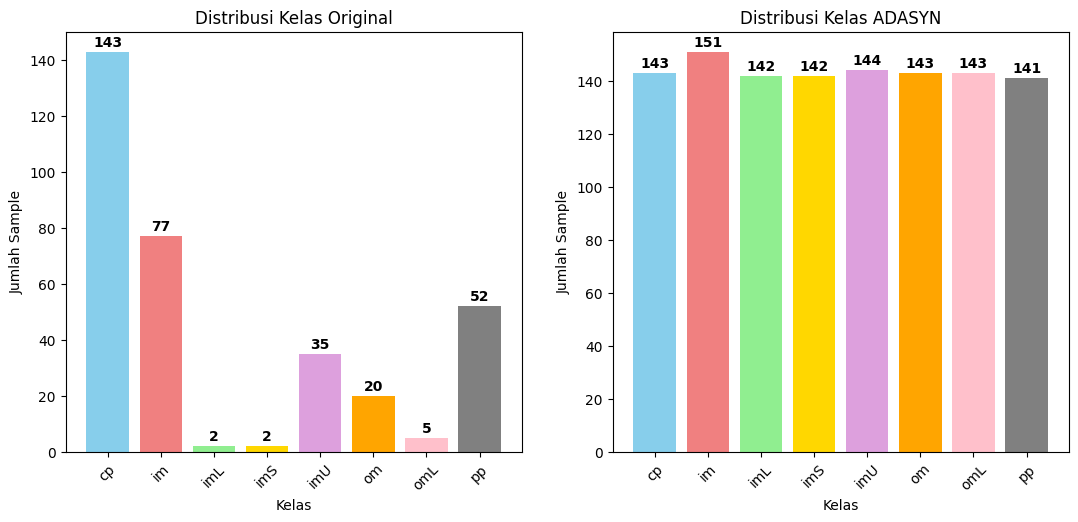

In [6]:
# Visualisasi distribusi
plt.figure(figsize=(20, 12))

original_counts = Counter(y_orig)
adasyn_counts = Counter(y_adasyn)
classes = sorted(original_counts.keys())

original_values = [original_counts[cls] for cls in classes]
adasyn_values = [adasyn_counts[cls] for cls in classes]

# Plot 1: Original
plt.subplot(2, 3, 1)
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'gray']
bars1 = plt.bar(classes, original_values, color=colors[:len(classes)])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sample')
plt.title('Distribusi Kelas Original')
plt.xticks(rotation=45)

for bar, count in zip(bars1, original_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold')

# Plot 2: ADASYN
plt.subplot(2, 3, 2)
bars2 = plt.bar(classes, adasyn_values, color=colors[:len(classes)])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sample')
plt.title('Distribusi Kelas ADASYN')
plt.xticks(rotation=45)

for bar, count in zip(bars2, adasyn_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold')

#### **1.1.4 Visualisasi Perbandingan Accuracy**

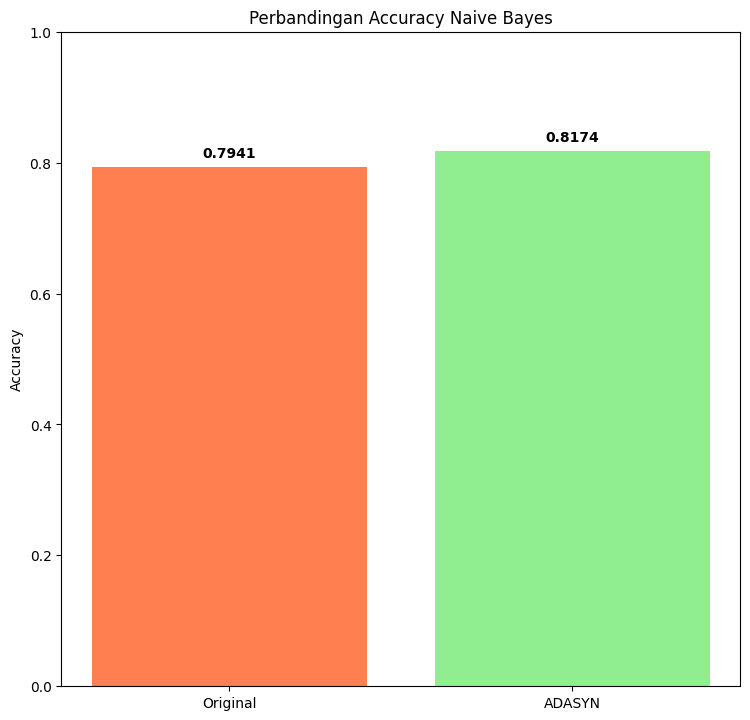

In [7]:
# Plot 3: Perbandingan Accuracy
plt.figure(figsize=(22,14))
plt.subplot(2, 3, 3)
acc_comparison = [accuracy_score(y_test_orig, y_pred_orig), 
                accuracy_score(y_test_adasyn, y_pred_adasyn)]
methods = ['Original', 'ADASYN']
bars = plt.bar(methods, acc_comparison, color=['coral', 'lightgreen'])
plt.ylabel('Accuracy')
plt.title('Perbandingan Accuracy Naive Bayes')
plt.ylim(0, 1)

for bar, acc in zip(bars, acc_comparison):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### **1.2 Klasifikasi Ecoli SMOTE (Naive Bayes)**

#### **1.2.1 Pengambilan Data**

In [8]:
# === KLASIFIKASI SMOTE MENGGUNAKAN NAIVE BAYES ===
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

df_original = pd.read_csv('data_ecoli_original.csv')
df_smote = pd.read_csv('data_ecoli_smote.csv')

X_orig = df_original[['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']]
y_orig = df_original['class']

X_smote = df_smote[['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']]
y_smote = df_smote['class']

print("\n" + "="*60)
print("KLASIFIKASI SMOTE MENGGUNAKAN NAIVE BAYES")
print("="*60)

print("Distribusi kelas sebelum SMOTE:")
print(f"{sorted(Counter(y_orig).items())}")

print(f"\nDistribusi kelas setelah SMOTE:")
print(f"{sorted(Counter(y_smote).items())}")

print(f"\nTotal samples sebelum: {len(y_orig)}")
print(f"Total samples setelah: {len(y_smote)}")
print(f"Data yang ditambahkan: {len(y_smote) - len(y_orig)}")


KLASIFIKASI SMOTE MENGGUNAKAN NAIVE BAYES
Distribusi kelas sebelum SMOTE:
[('cp', 143), ('im', 77), ('imL', 2), ('imS', 2), ('imU', 35), ('om', 20), ('omL', 5), ('pp', 52)]

Distribusi kelas setelah SMOTE:
[('cp', 143), ('im', 143), ('imL', 143), ('imS', 143), ('imU', 143), ('om', 143), ('omL', 143), ('pp', 143)]

Total samples sebelum: 336
Total samples setelah: 1144
Data yang ditambahkan: 808


#### **1.2.2 Klasifikasi Naive Bayes**

In [9]:
# 1. Klasifikasi data SEBELUM SMOTE
print("\n--- KLASIFIKASI DATA SEBELUM SMOTE ---")
X_train_orig_smote, X_test_orig_smote, y_train_orig_smote, y_test_orig_smote = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)
nb_orig_smote = GaussianNB()
nb_orig_smote.fit(X_train_orig_smote, y_train_orig_smote)
y_pred_orig_smote = nb_orig_smote.predict(X_test_orig_smote)

print(f"Accuracy data SEBELUM SMOTE: {accuracy_score(y_test_orig_smote, y_pred_orig_smote):.4f}")
print("\nClassification Report - SEBELUM SMOTE:")
print(classification_report(y_test_orig_smote, y_pred_orig_smote, zero_division=0))


--- KLASIFIKASI DATA SEBELUM SMOTE ---
Accuracy data SEBELUM SMOTE: 0.7941

Classification Report - SEBELUM SMOTE:
              precision    recall  f1-score   support

          cp       0.97      1.00      0.98        29
          im       1.00      0.44      0.61        16
         imU       0.50      0.86      0.63         7
          om       0.00      0.00      0.00         4
         omL       1.00      1.00      1.00         1
          pp       0.61      1.00      0.76        11

    accuracy                           0.79        68
   macro avg       0.68      0.72      0.66        68
weighted avg       0.81      0.79      0.76        68



In [10]:
# 2. Klasifikasi data SETELAH SMOTE
print("\n--- KLASIFIKASI DATA SETELAH SMOTE ---")
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

nb_smote = GaussianNB()
nb_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = nb_smote.predict(X_test_smote)

print(f"Accuracy data SETELAH SMOTE: {accuracy_score(y_test_smote, y_pred_smote):.4f}")
print("\nClassification Report - SETELAH SMOTE:")
print(classification_report(y_test_smote, y_pred_smote, zero_division=0))


--- KLASIFIKASI DATA SETELAH SMOTE ---
Accuracy data SETELAH SMOTE: 0.8428

Classification Report - SETELAH SMOTE:
              precision    recall  f1-score   support

          cp       0.80      1.00      0.89        28
          im       1.00      0.50      0.67        28
         imL       1.00      1.00      1.00        29
         imS       1.00      1.00      1.00        29
         imU       0.81      0.86      0.83        29
          om       1.00      0.43      0.60        28
         omL       1.00      1.00      1.00        29
          pp       0.54      0.93      0.68        29

    accuracy                           0.84       229
   macro avg       0.89      0.84      0.83       229
weighted avg       0.89      0.84      0.84       229




Confusion Matrix - Original:
[[29  0  0  0  0  0  0  0]
 [ 1  7  0  0  6  0  0  2]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  1]
 [ 0  0  0  0  0  0  0  4]
 [ 0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0 11]]

Confusion Matrix - SMOTE:
[[28  0  0  0  0  0  0  0]
 [ 5 14  0  0  6  0  0  3]
 [ 0  0 29  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0]
 [ 0  0  0  0 25  0  0  4]
 [ 0  0  0  0  0 12  0 16]
 [ 0  0  0  0  0  0 29  0]
 [ 2  0  0  0  0  0  0 27]]


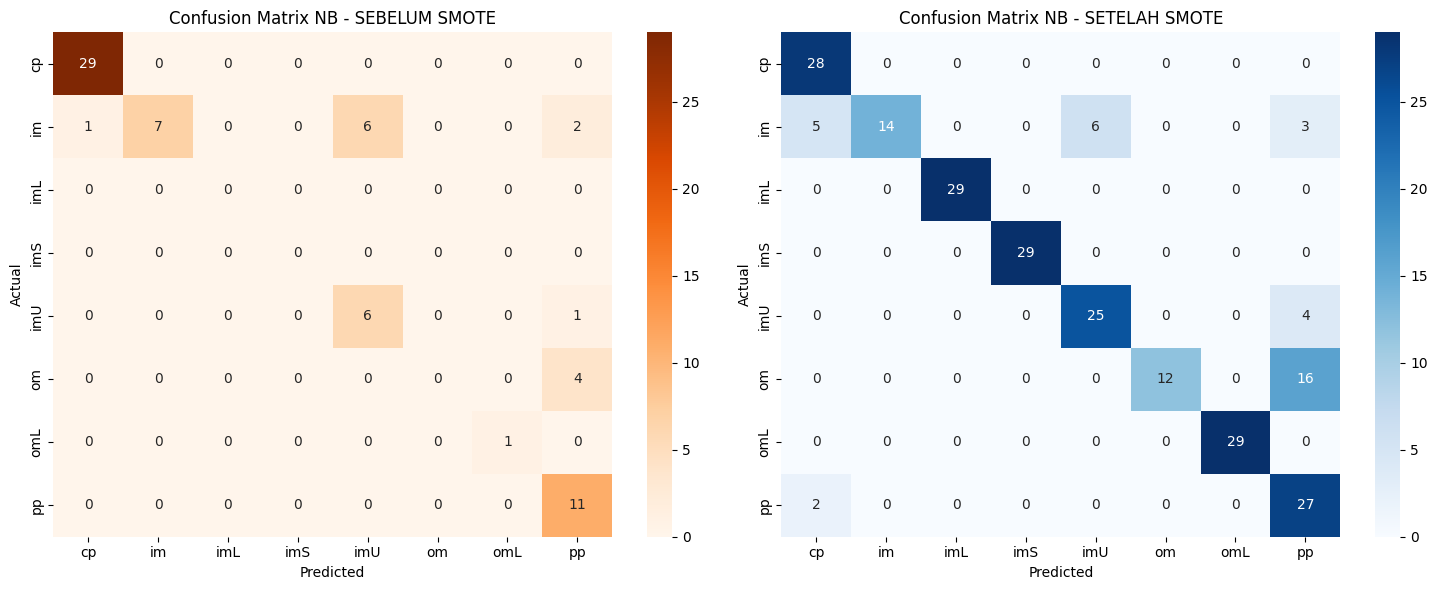

In [11]:
# Confusion Matrix - Original
labels = sorted(y_orig.unique())
print("\nConfusion Matrix - Original:")
cm_orig_smote = confusion_matrix(y_test_orig_smote, y_pred_orig_smote, labels=labels)
print(cm_orig_smote)

# Confusion Matrix - SMOTE
print("\nConfusion Matrix - SMOTE:")
cm_smote = confusion_matrix(y_test_smote, y_pred_smote)
print(cm_smote)

# Visualisasi Confusion Matrix
plt.figure(figsize=(15, 6))

# Plot Confusion Matrix SEBELUM SMOTE
plt.subplot(1, 2, 1)
sns.heatmap(cm_orig_smote, annot=True, fmt='d', cmap='Oranges', 
           xticklabels=labels, 
           yticklabels=labels)
plt.title('Confusion Matrix NB - SEBELUM SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot Confusion Matrix SETELAH SMOTE
plt.subplot(1, 2, 2)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues',
           xticklabels=sorted(y_smote.unique()), 
           yticklabels=sorted(y_smote.unique()))
plt.title('Confusion Matrix NB - SETELAH SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

#### **1.2.3 Visualisasi Distribusi Kelas**

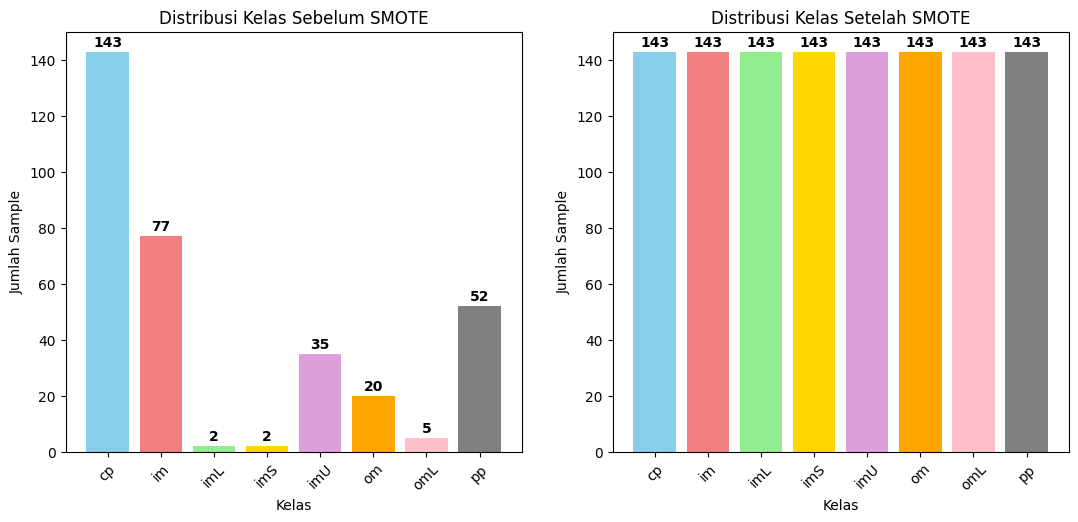

In [12]:
plt.figure(figsize=(20, 12))

original_counts_smote = Counter(y_orig)
smote_counts = Counter(y_smote)
classes = sorted(original_counts_smote.keys())

original_values = [original_counts_smote[cls] for cls in classes]
smote_values = [smote_counts[cls] for cls in classes]

# Plot 1: Sebelum SMOTE
plt.subplot(2, 3, 1)
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'gray']
bars1 = plt.bar(classes, original_values, color=colors[:len(classes)])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sample')
plt.title('Distribusi Kelas Sebelum SMOTE')
plt.xticks(rotation=45)

for bar, count in zip(bars1, original_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold')

# Plot 2: Setelah SMOTE
plt.subplot(2, 3, 2)
bars2 = plt.bar(classes, smote_values, color=colors[:len(classes)])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sample')
plt.title('Distribusi Kelas Setelah SMOTE')
plt.xticks(rotation=45)

for bar, count in zip(bars2, smote_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold')

#### **1.2.4 Visualisasi Perbandingan Accuracy**

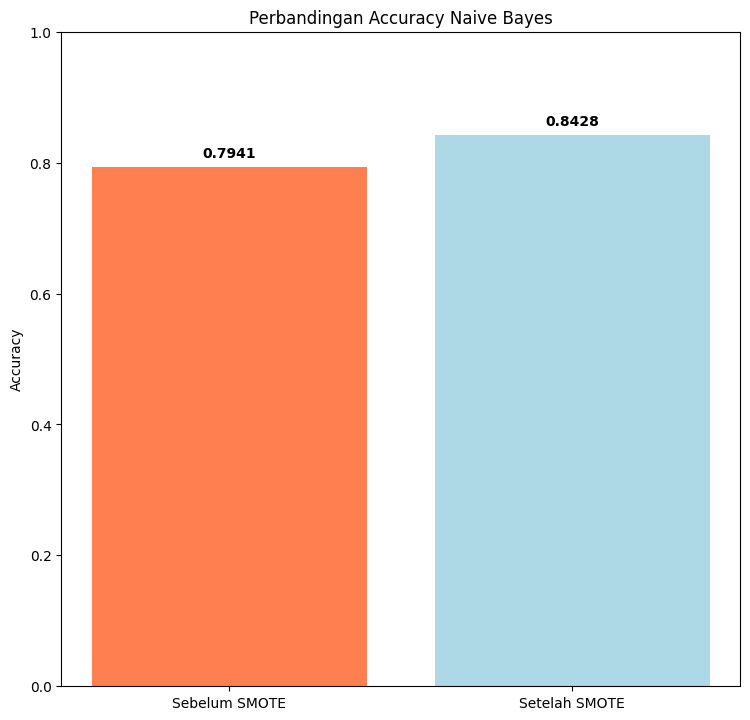

In [13]:
# Plot 3: Perbandingan Accuracy
plt.figure(figsize=(22,14))
plt.subplot(2, 3, 3)
acc_comparison = [accuracy_score(y_test_orig_smote, y_pred_orig_smote), 
                accuracy_score(y_test_smote, y_pred_smote)]
methods = ['Sebelum SMOTE', 'Setelah SMOTE']
bars = plt.bar(methods, acc_comparison, color=['coral', 'lightblue'])
plt.ylabel('Accuracy')
plt.title('Perbandingan Accuracy Naive Bayes')
plt.ylim(0, 1)

for bar, acc in zip(bars, acc_comparison):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## **2. Klasifikasi Ecoli ADASAYN Dan SMOTE Menggunakan Random Forest**

### **2.1 Klasifikasi Ecoli ADASYN (Random Forest)**

#### **2.1.1 Pengambilan Data**

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
from collections import Counter

df_original = pd.read_csv('data_ecoli_original.csv')
X_orig = df_original[['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']]
y_orig = df_original['class']

df_adasyn = pd.read_csv('data_ecoli_adasyn.csv')
X_adasyn_rf = df_adasyn[['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']]
y_adasyn_rf = df_adasyn['class']



print("Distribusi kelas sebelum ADASYN:")
print(f"{sorted(Counter(y_orig).items())}")

print(f"\nDistribusi kelas setelah ADASYN:")
print(f"{sorted(Counter(y_adasyn_rf).items())}")

print(f"\nTotal samples sebelum: {len(y_orig)}")
print(f"Total samples setelah: {len(y_adasyn_rf)}")
print(f"Data yang ditambahkan: {len(y_adasyn_rf) - len(y_orig)}")

Distribusi kelas sebelum ADASYN:
[('cp', 143), ('im', 77), ('imL', 2), ('imS', 2), ('imU', 35), ('om', 20), ('omL', 5), ('pp', 52)]

Distribusi kelas setelah ADASYN:
[('cp', 143), ('im', 151), ('imL', 142), ('imS', 142), ('imU', 144), ('om', 143), ('omL', 143), ('pp', 141)]

Total samples sebelum: 336
Total samples setelah: 1149
Data yang ditambahkan: 813


#### **2.1.2 Klasifikasi Random Forest**

In [15]:
# === KLASIFIKASI MENGGUNAKAN RANDOM FOREST ===

print("\n" + "="*60)
print("KLASIFIKASI MENGGUNAKAN RANDOM FOREST")
print("="*60)

# 1. Klasifikasi data SEBELUM ADASYN
print("\n--- KLASIFIKASI DATA SEBELUM ADASYN ---")
X_train_orig_rf, X_test_orig_rf, y_train_orig_rf, y_test_orig_rf = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

rf_orig = RandomForestClassifier(n_estimators=100, random_state=42)
rf_orig.fit(X_train_orig_rf, y_train_orig_rf)
y_pred_orig_rf = rf_orig.predict(X_test_orig_rf)

print(f"Accuracy data SEBELUM ADASYN: {accuracy_score(y_test_orig_rf, y_pred_orig_rf):.4f}")
print("\nClassification Report - SEBELUM ADASYN:")
print(classification_report(y_test_orig_rf, y_pred_orig_rf, zero_division=0))


KLASIFIKASI MENGGUNAKAN RANDOM FOREST

--- KLASIFIKASI DATA SEBELUM ADASYN ---
Accuracy data SEBELUM ADASYN: 0.8676

Classification Report - SEBELUM ADASYN:
              precision    recall  f1-score   support

          cp       0.94      1.00      0.97        29
          im       0.91      0.62      0.74        16
         imU       0.50      0.86      0.63         7
          om       1.00      1.00      1.00         4
         omL       1.00      1.00      1.00         1
          pp       1.00      0.82      0.90        11

    accuracy                           0.87        68
   macro avg       0.89      0.88      0.87        68
weighted avg       0.90      0.87      0.87        68



In [16]:
# 2. Klasifikasi data SETELAH ADASYN
print("\n--- KLASIFIKASI DATA SETELAH ADASYN ---")
X_train_adasyn_rf, X_test_adasyn_rf, y_train_adasyn_rf, y_test_adasyn_rf = train_test_split(
    X_adasyn_rf, y_adasyn_rf, test_size=0.2, random_state=42, stratify=y_adasyn_rf
)

rf_adasyn = RandomForestClassifier(n_estimators=100, random_state=42)
rf_adasyn.fit(X_train_adasyn_rf, y_train_adasyn_rf)
y_pred_adasyn_rf = rf_adasyn.predict(X_test_adasyn_rf)

print(f"Accuracy data SETELAH ADASYN: {accuracy_score(y_test_adasyn_rf, y_pred_adasyn_rf):.4f}")
print("\nClassification Report - SETELAH ADASYN:")
print(classification_report(y_test_adasyn_rf, y_pred_adasyn_rf, zero_division=0))


--- KLASIFIKASI DATA SETELAH ADASYN ---


Accuracy data SETELAH ADASYN: 0.9478

Classification Report - SETELAH ADASYN:


              precision    recall  f1-score   support

          cp       0.94      1.00      0.97        29
          im       0.81      0.87      0.84        30
         imL       1.00      1.00      1.00        28
         imS       1.00      1.00      1.00        28
         imU       0.86      0.83      0.84        29
          om       1.00      1.00      1.00        29
         omL       1.00      1.00      1.00        29
          pp       1.00      0.89      0.94        28

    accuracy                           0.95       230
   macro avg       0.95      0.95      0.95       230
weighted avg       0.95      0.95      0.95       230




Confusion Matrix - SEBELUM ADASYN:
[[29  0  0  0  0  0  0  0]
 [ 0 10  0  0  6  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  1  0  0  6  0  0  0]
 [ 0  0  0  0  0  4  0  0]
 [ 0  0  0  0  0  0  1  0]
 [ 2  0  0  0  0  0  0  9]]

Confusion Matrix - SETELAH ADASYN:
[[29  0  0  0  0  0  0  0]
 [ 0 26  0  0  4  0  0  0]
 [ 0  0 28  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0]
 [ 0  5  0  0 24  0  0  0]
 [ 0  0  0  0  0 29  0  0]
 [ 0  0  0  0  0  0 29  0]
 [ 2  1  0  0  0  0  0 25]]


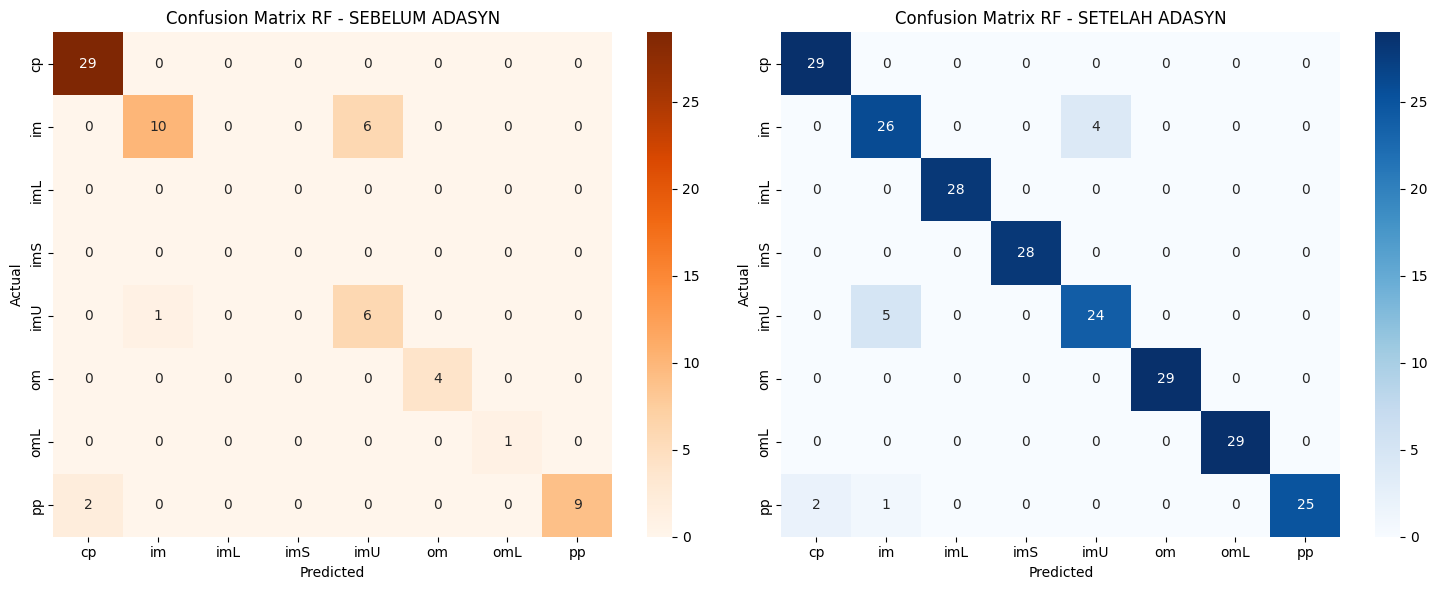

In [17]:
# Confusion Matrix - SEBELUM ADASYN
labels = sorted(y_orig.unique())
print("\nConfusion Matrix - SEBELUM ADASYN:")
cm_orig_rf = confusion_matrix(y_test_orig_rf, y_pred_orig_rf, labels=labels)
print(cm_orig_rf)

# Confusion Matrix - SETELAH ADASYN
print("\nConfusion Matrix - SETELAH ADASYN:")
cm_adasyn_rf = confusion_matrix(y_test_adasyn_rf, y_pred_adasyn_rf)
print(cm_adasyn_rf)

# Visualisasi Confusion Matrix
plt.figure(figsize=(15, 6))

# Plot Confusion Matrix SEBELUM ADASYN
plt.subplot(1, 2, 1)
sns.heatmap(cm_orig_rf, annot=True, fmt='d', cmap='Oranges', 
           xticklabels=labels, 
           yticklabels=labels)
plt.title('Confusion Matrix RF - SEBELUM ADASYN')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot Confusion Matrix SETELAH ADASYN
plt.subplot(1, 2, 2)
sns.heatmap(cm_adasyn_rf, annot=True, fmt='d', cmap='Blues',
           xticklabels=sorted(y_adasyn_rf.unique()), 
           yticklabels=sorted(y_adasyn_rf.unique()))
plt.title('Confusion Matrix RF - SETELAH ADASYN')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

#### **2.1.3 Visualisasi Distribusi Kelas**

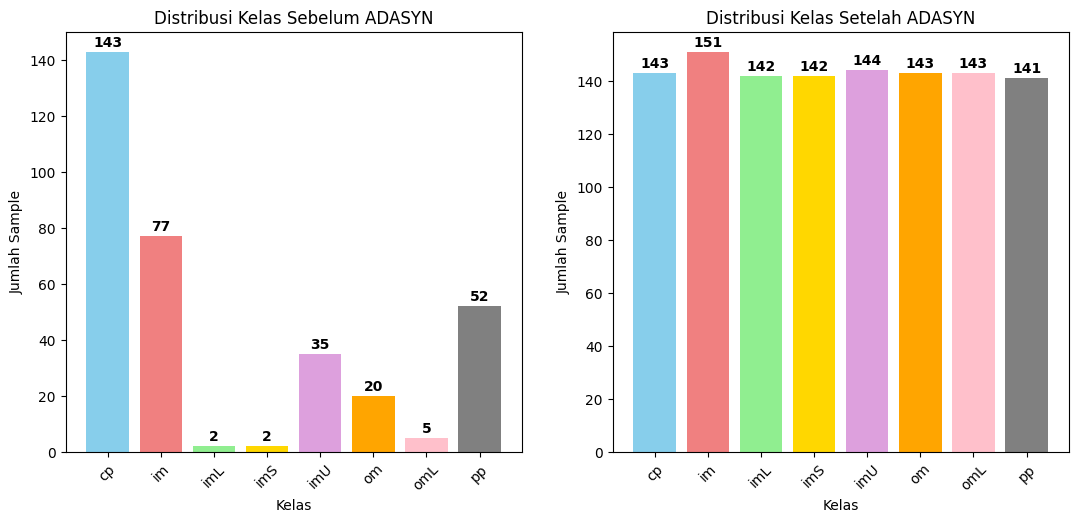

In [18]:
plt.figure(figsize=(20, 12))

original_counts = Counter(y_orig)
adasyn_counts = Counter(y_adasyn_rf)
classes = sorted(original_counts.keys())

original_values = [original_counts[cls] for cls in classes]
adasyn_values = [adasyn_counts[cls] for cls in classes]

# Plot 1: Sebelum ADASYN
plt.subplot(2, 3, 1)
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'gray']
bars1 = plt.bar(classes, original_values, color=colors[:len(classes)])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sample')
plt.title('Distribusi Kelas Sebelum ADASYN')
plt.xticks(rotation=45)

for bar, count in zip(bars1, original_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold')

# Plot 2: Setelah ADASYN
plt.subplot(2, 3, 2)
bars2 = plt.bar(classes, adasyn_values, color=colors[:len(classes)])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sample')
plt.title('Distribusi Kelas Setelah ADASYN')
plt.xticks(rotation=45)

for bar, count in zip(bars2, adasyn_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold')

#### **2.1.4 Visualisasi Perbandingan Accuracy**

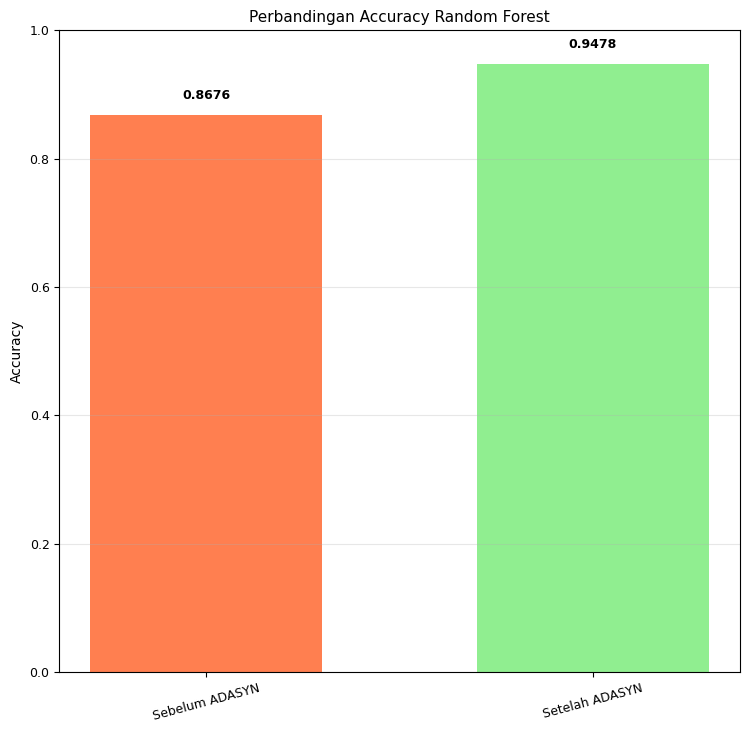

In [19]:
# Plot 3: Perbandingan Accuracy
plt.figure(figsize=(22,14))
plt.subplot(2, 3, 3)
acc_comparison = [accuracy_score(y_test_orig_rf, y_pred_orig_rf), 
                accuracy_score(y_test_adasyn_rf, y_pred_adasyn_rf)]
methods = ['Sebelum ADASYN', 'Setelah ADASYN']
bars = plt.bar(methods, acc_comparison, color=['coral', 'lightgreen'], width=0.6)
plt.ylabel('Accuracy')
plt.title('Perbandingan Accuracy Random Forest', fontsize=11)
plt.ylim(0, 1)
plt.xticks(fontsize=9, rotation=15)
plt.yticks(fontsize=9)

for bar, acc in zip(bars, acc_comparison):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### **2.2 Klasifikasi Ecoli SMOTE (Random Forest)**

#### **2.2.1 Pengambilan Data**

In [20]:
print("\n" + "="*60)
print("KLASIFIKASI SMOTE MENGGUNAKAN RANDOM FOREST")
print("="*60)


df_smote_rf = pd.read_csv('data_ecoli_smote.csv')
X_smote_rf = df_smote_rf[['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']]
y_smote_rf = df_smote_rf['class']

df_original_rf = pd.read_csv('data_ecoli_original.csv')
X_original_rf = df_original_rf[['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']]
y_original_rf = df_original_rf['class']

print("Distribusi kelas sebelum SMOTE:")
print(f"{sorted(Counter(y_orig).items())}")

print(f"\nDistribusi kelas setelah SMOTE:")
print(f"{sorted(Counter(y_smote_rf).items())}")

print(f"\nTotal samples sebelum: {len(y_original_rf)}")
print(f"Total samples setelah: {len(y_smote_rf)}")
print(f"Data yang ditambahkan: {len(y_smote_rf) - len(y_original_rf)}")


KLASIFIKASI SMOTE MENGGUNAKAN RANDOM FOREST
Distribusi kelas sebelum SMOTE:
[('cp', 143), ('im', 77), ('imL', 2), ('imS', 2), ('imU', 35), ('om', 20), ('omL', 5), ('pp', 52)]

Distribusi kelas setelah SMOTE:
[('cp', 143), ('im', 143), ('imL', 143), ('imS', 143), ('imU', 143), ('om', 143), ('omL', 143), ('pp', 143)]

Total samples sebelum: 336
Total samples setelah: 1144
Data yang ditambahkan: 808


#### **2.2.2 Klasifikasi Random Forest**

In [21]:
# 1. Klasifikasi data SEBELUM SMOTE
print("\n--- KLASIFIKASI DATA SEBELUM SMOTE ---")
X_train_orig_smote_rf, X_test_orig_smote_rf, y_train_orig_smote_rf, y_test_orig_smote_rf = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

rf_orig_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_orig_smote.fit(X_train_orig_smote_rf, y_train_orig_smote_rf)
y_pred_orig_smote_rf = rf_orig_smote.predict(X_test_orig_smote_rf)

print(f"Accuracy data SEBELUM SMOTE: {accuracy_score(y_test_orig_smote_rf, y_pred_orig_smote_rf):.4f}")
print("\nClassification Report - SEBELUM SMOTE:")
print(classification_report(y_test_orig_smote_rf, y_pred_orig_smote_rf, zero_division=0))


--- KLASIFIKASI DATA SEBELUM SMOTE ---
Accuracy data SEBELUM SMOTE: 0.8676

Classification Report - SEBELUM SMOTE:
              precision    recall  f1-score   support

          cp       0.94      1.00      0.97        29
          im       0.91      0.62      0.74        16
         imU       0.50      0.86      0.63         7
          om       1.00      1.00      1.00         4
         omL       1.00      1.00      1.00         1
          pp       1.00      0.82      0.90        11

    accuracy                           0.87        68
   macro avg       0.89      0.88      0.87        68
weighted avg       0.90      0.87      0.87        68



In [22]:
# 2. Klasifikasi data SETELAH SMOTE
print("\n--- KLASIFIKASI DATA SETELAH SMOTE ---")
X_train_smote_rf, X_test_smote_rf, y_train_smote_rf, y_test_smote_rf = train_test_split(
    X_smote_rf, y_smote_rf, test_size=0.2, random_state=42, stratify=y_smote_rf
)

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote_rf, y_train_smote_rf)
y_pred_smote_rf = rf_smote.predict(X_test_smote_rf)

print(f"Accuracy data SETELAH SMOTE: {accuracy_score(y_test_smote_rf, y_pred_smote_rf):.4f}")
print("\nClassification Report - SETELAH SMOTE:")
print(classification_report(y_test_smote_rf, y_pred_smote_rf, zero_division=0))


--- KLASIFIKASI DATA SETELAH SMOTE ---


Accuracy data SETELAH SMOTE: 0.9520

Classification Report - SETELAH SMOTE:
              precision    recall  f1-score   support

          cp       0.88      1.00      0.93        28
          im       0.89      0.86      0.87        28
         imL       1.00      1.00      1.00        29
         imS       1.00      1.00      1.00        29
         imU       0.89      0.86      0.88        29
          om       1.00      0.96      0.98        28
         omL       1.00      1.00      1.00        29
          pp       0.96      0.93      0.95        29

    accuracy                           0.95       229
   macro avg       0.95      0.95      0.95       229
weighted avg       0.95      0.95      0.95       229




Confusion Matrix - SEBELUM SMOTE:
[[29  0  0  0  0  0  0  0]
 [ 0 10  0  0  6  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  1  0  0  6  0  0  0]
 [ 0  0  0  0  0  4  0  0]
 [ 0  0  0  0  0  0  1  0]
 [ 2  0  0  0  0  0  0  9]]

Confusion Matrix - SETELAH SMOTE:
[[28  0  0  0  0  0  0  0]
 [ 1 24  0  0  3  0  0  0]
 [ 0  0 29  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0]
 [ 1  3  0  0 25  0  0  0]
 [ 0  0  0  0  0 27  0  1]
 [ 0  0  0  0  0  0 29  0]
 [ 2  0  0  0  0  0  0 27]]


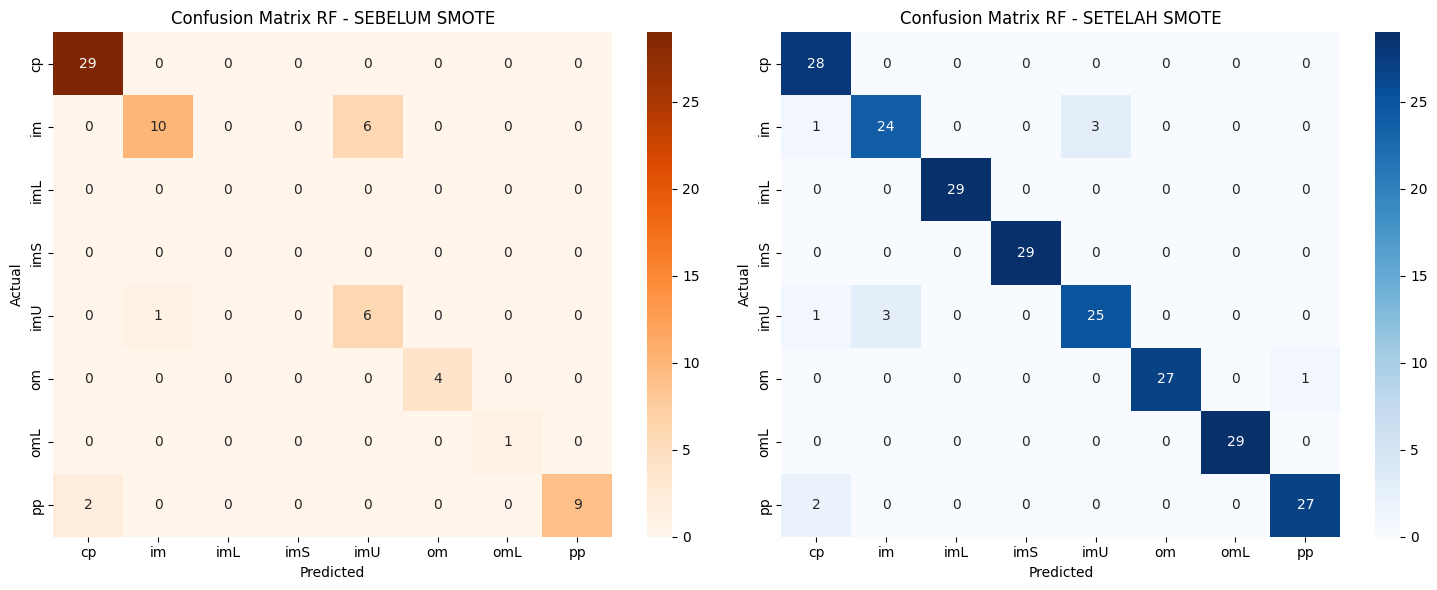

In [23]:
# Confusion Matrix - SEBELUM SMOTE
labels = sorted(y_orig.unique())
print("\nConfusion Matrix - SEBELUM SMOTE:")
cm_orig_smote_rf = confusion_matrix(y_test_orig_smote_rf, y_pred_orig_smote_rf, labels=labels)
print(cm_orig_smote_rf)

# Confusion Matrix - SETELAH SMOTE
print("\nConfusion Matrix - SETELAH SMOTE:")
cm_smote_rf = confusion_matrix(y_test_smote_rf, y_pred_smote_rf)
print(cm_smote_rf)

# Visualisasi Confusion Matrix
plt.figure(figsize=(15, 6))

# Plot Confusion Matrix SEBELUM SMOTE
plt.subplot(1, 2, 1)
sns.heatmap(cm_orig_smote_rf, annot=True, fmt='d', cmap='Oranges', 
           xticklabels=labels, 
           yticklabels=labels)
plt.title('Confusion Matrix RF - SEBELUM SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot Confusion Matrix SETELAH SMOTE
plt.subplot(1, 2, 2)
sns.heatmap(cm_smote_rf, annot=True, fmt='d', cmap='Blues',
           xticklabels=sorted(y_smote_rf.unique()), 
           yticklabels=sorted(y_smote_rf.unique()))
plt.title('Confusion Matrix RF - SETELAH SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

#### **2.2.3 Visualisasi Distribusi Kelas**

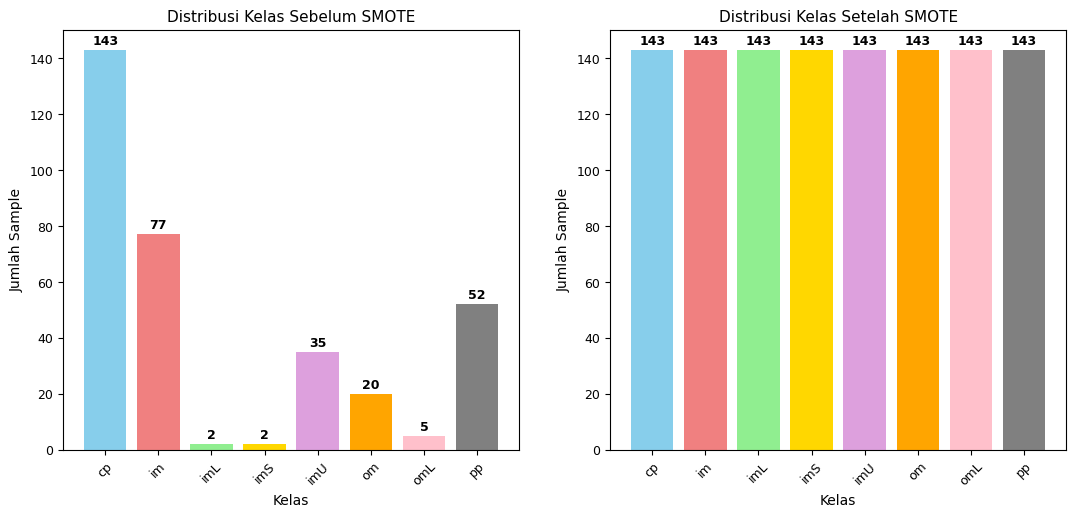

In [24]:
plt.figure(figsize=(20, 12))

original_counts_smote = Counter(y_orig)
smote_counts = Counter(y_smote_rf)
classes = sorted(original_counts_smote.keys())

original_values = [original_counts_smote[cls] for cls in classes]
smote_values = [smote_counts[cls] for cls in classes]

# Plot 1: Sebelum SMOTE
plt.subplot(2, 3, 1)
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange', 'pink', 'gray']
bars1 = plt.bar(classes, original_values, color=colors[:len(classes)])
plt.xlabel('Kelas', fontsize=10)
plt.ylabel('Jumlah Sample', fontsize=10)
plt.title('Distribusi Kelas Sebelum SMOTE', fontsize=11)
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)

for bar, count in zip(bars1, original_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Setelah SMOTE
plt.subplot(2, 3, 2)
bars2 = plt.bar(classes, smote_values, color=colors[:len(classes)])
plt.xlabel('Kelas', fontsize=10)
plt.ylabel('Jumlah Sample', fontsize=10)
plt.title('Distribusi Kelas Setelah SMOTE', fontsize=11)
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)

for bar, count in zip(bars2, smote_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)

#### **2.1.4 Visualisasi Perbandingan Accuracy**

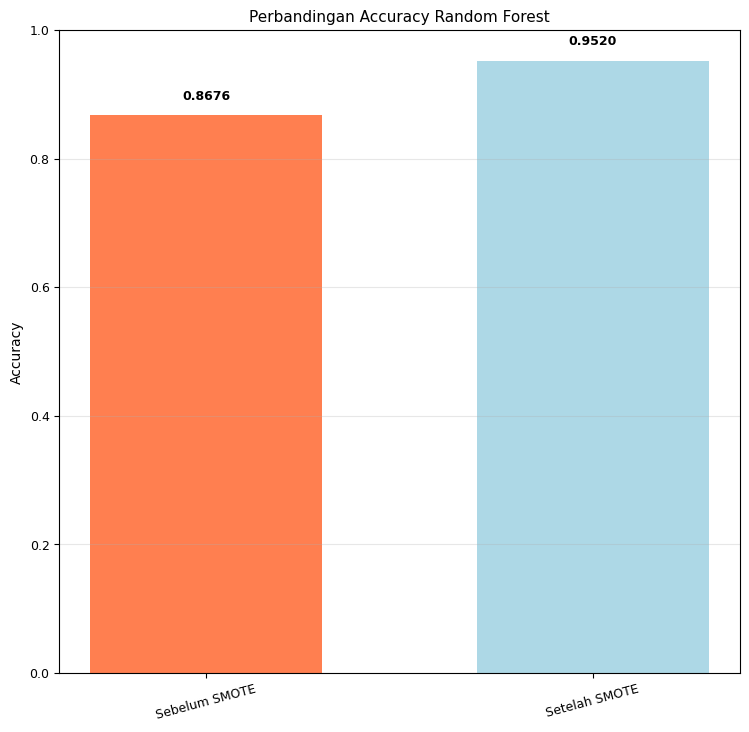

In [25]:
# Plot 3: Perbandingan Accuracy
plt.figure(figsize=(22,14))
plt.subplot(2, 3, 3)
acc_comparison = [accuracy_score(y_test_orig_smote_rf, y_pred_orig_smote_rf), 
                accuracy_score(y_test_smote_rf, y_pred_smote_rf)]
methods = ['Sebelum SMOTE', 'Setelah SMOTE']
bars = plt.bar(methods, acc_comparison, color=['coral', 'lightblue'], width=0.6)
plt.ylabel('Accuracy', fontsize=10)
plt.title('Perbandingan Accuracy Random Forest', fontsize=11)
plt.ylim(0, 1)
plt.xticks(fontsize=9, rotation=15)
plt.yticks(fontsize=9)

for bar, acc in zip(bars, acc_comparison):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## **3. Perbandingan Accuracy Tiap Model Klasifikasi**

#### **3.1 Perbandingan Accuracy Klasifikasi Naive Bayes**

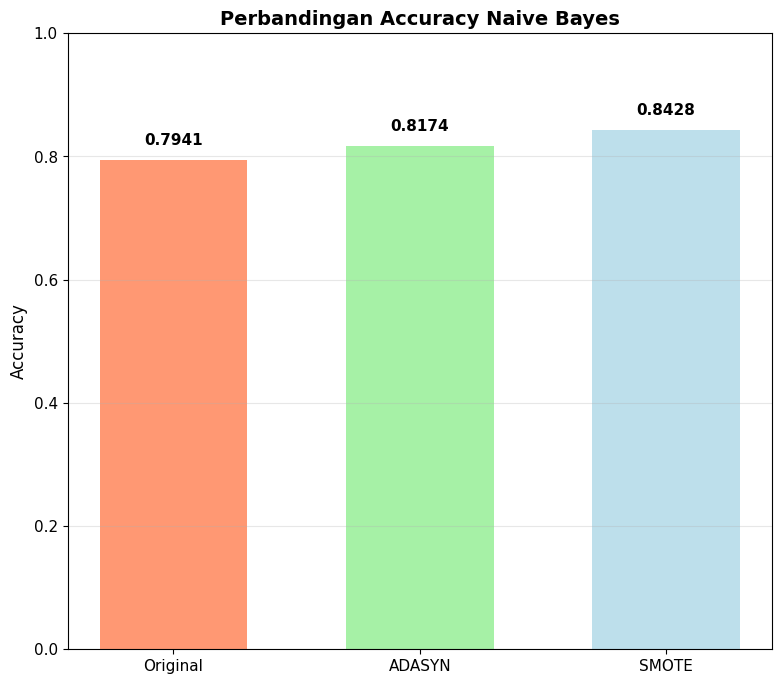

In [26]:
nb_original_acc = accuracy_score(y_test_orig, y_pred_orig)
nb_adasyn_acc = accuracy_score(y_test_adasyn, y_pred_adasyn)
nb_smote_acc = accuracy_score(y_test_smote, y_pred_smote)


methods = ['Original', 'ADASYN', 'SMOTE']
nb_accuracies = [nb_original_acc, nb_adasyn_acc, nb_smote_acc]

plt.figure(figsize=(20, 8))

# Plot 1: Naive Bayes Accuracy Comparison
plt.subplot(1, 2, 1)
colors_nb = ['coral', 'lightgreen', 'lightblue']
bars_nb = plt.bar(methods, nb_accuracies, color=colors_nb, width=0.6, alpha=0.8)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Perbandingan Accuracy Naive Bayes', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add value labels on bars
for bar, acc in zip(bars_nb, nb_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(True, alpha=0.3, axis='y')


#### **3.2 Perbandingan Accuracy Klasifikasi Random Forest**

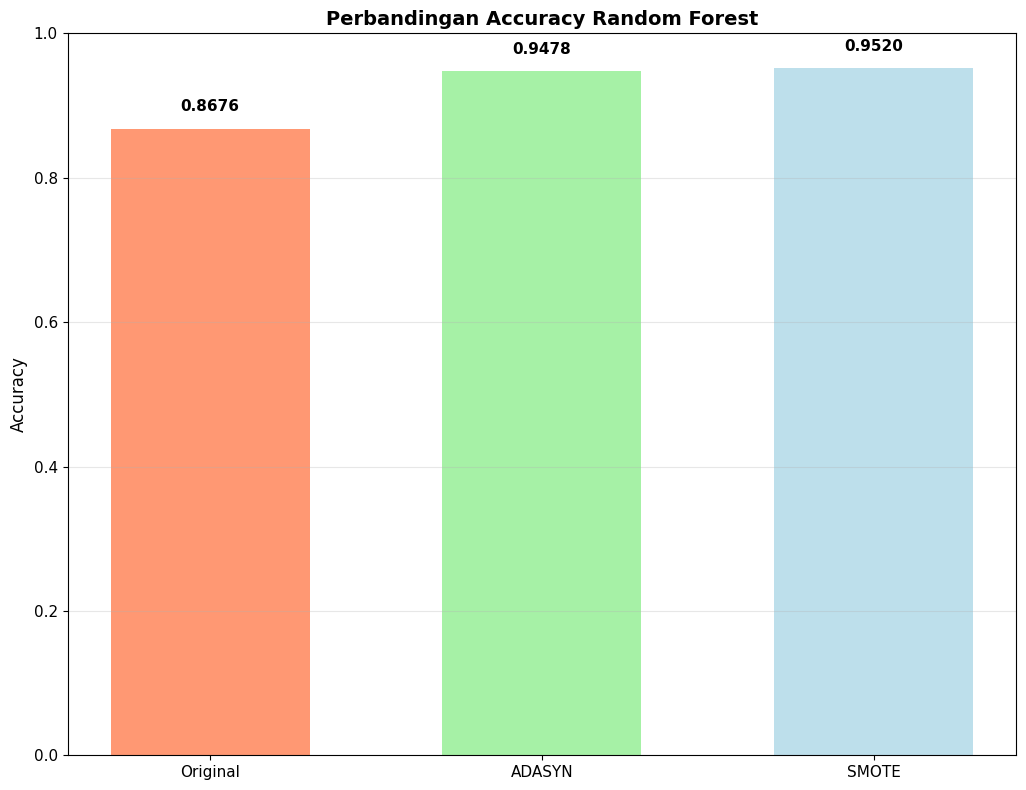

In [27]:
rf_original_acc = accuracy_score(y_test_orig_rf, y_pred_orig_rf)
rf_adasyn_acc = accuracy_score(y_test_adasyn_rf, y_pred_adasyn_rf)
rf_smote_acc = accuracy_score(y_test_smote_rf, y_pred_smote_rf)

methods = ['Original', 'ADASYN', 'SMOTE']
rf_accuracies = [rf_original_acc, rf_adasyn_acc, rf_smote_acc]

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 2)
colors_rf = ['coral', 'lightgreen', 'lightblue']
bars_rf = plt.bar(methods, rf_accuracies, color=colors_rf, width=0.6, alpha=0.8)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Perbandingan Accuracy Random Forest', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

for bar, acc in zip(bars_rf, rf_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## **4. Ecoli BaggingClassifier**

Import Library Yang Di Butuhkan

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import BaggingClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

Baca File CSV "data_ecoli_original" 

In [29]:
data_origin = pd.read_csv("data_ecoli_original.csv")
print(data_origin['class'].value_counts())
X_origin = data_origin.drop(columns=["class","id","Sequence"])
y_origin = data_origin["class"]
data_origin

class
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imS      2
imL      2
Name: count, dtype: int64


,id,Sequence,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,1,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,2,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,3,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,4,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,5,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp
...,...,...,...,...,...,...,...,...,...,...
331,332,TREA_ECOLI,0.74,0.56,0.48,0.5,0.47,0.68,0.30,pp
332,333,UGPB_ECOLI,0.71,0.57,0.48,0.5,0.48,0.35,0.32,pp
333,334,USHA_ECOLI,0.61,0.60,0.48,0.5,0.44,0.39,0.38,pp
334,335,XYLF_ECOLI,0.59,0.61,0.48,0.5,0.42,0.42,0.37,pp


Baca File CSV "data_ecoli_adasyn" 

In [30]:
data_adasyn = pd.read_csv("data_ecoli_adasyn.csv")
x_adasyn = data_adasyn.drop(columns=["class"])
y_adasyn = data_adasyn["class"]
data_adasyn

,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,0.490000,0.290000,0.48,0.5,0.560000,0.240000,0.350000,cp
1,0.070000,0.400000,0.48,0.5,0.540000,0.350000,0.440000,cp
2,0.560000,0.400000,0.48,0.5,0.490000,0.370000,0.460000,cp
3,0.590000,0.490000,0.48,0.5,0.520000,0.450000,0.360000,cp
4,0.230000,0.320000,0.48,0.5,0.550000,0.250000,0.350000,cp
...,...,...,...,...,...,...,...,...
1144,0.234676,0.530988,0.48,0.5,0.363156,0.734410,0.555474,im
1145,0.386262,0.498869,0.48,0.5,0.303129,0.662870,0.334435,im
1146,0.582772,0.458655,0.48,0.5,0.120258,0.797731,0.431182,im
1147,0.528547,0.648547,0.48,0.5,0.575746,0.780726,0.737781,im


Baca File CSV "data_ecoli_smote" 

In [31]:
data_smote = pd.read_csv("data_ecoli_smote.csv")
x_smote = data_smote.drop(columns=["class"])
y_smote = data_smote["class"]
data_smote

,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,0.490000,0.290000,0.48,0.5,0.560000,0.240000,0.350000,cp
1,0.070000,0.400000,0.48,0.5,0.540000,0.350000,0.440000,cp
2,0.560000,0.400000,0.48,0.5,0.490000,0.370000,0.460000,cp
3,0.590000,0.490000,0.48,0.5,0.520000,0.450000,0.360000,cp
4,0.230000,0.320000,0.48,0.5,0.550000,0.250000,0.350000,cp
...,...,...,...,...,...,...,...,...
1139,0.660161,0.679839,0.48,0.5,0.615080,0.440214,0.400054,pp
1140,0.755882,0.732574,0.48,0.5,0.439485,0.392574,0.391544,pp
1141,0.632786,0.854427,0.48,0.5,0.384427,0.464427,0.356719,pp
1142,0.734496,0.747339,0.48,0.5,0.316421,0.541008,0.523669,pp


### **4.1 BaggingClassifier Naive Bayes**

#### **4.1.1 BaggingClassifier Naive Bayes Pada Data Original (Sebelum Oversampling)**

C:\Anaconda3\envs\py311\Lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
C:\Anaconda3\envs\py311\Lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
C:\Anaconda3\envs\py311\Lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
C:\Anaconda3\envs\py311\Lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
C:\Anaconda3\envs\py311\Lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
C:\Anaconda3\envs\py311\Lib\site-packages\sklearn\naive_bayes.py:509: RuntimeWarning: divide by zero encountered in log
  jointi = np.log(self.class_prior_[i])
C:\Anaconda3\envs\py311\Lib\site-package

Akurasi: 0.75
Classification Report:
               precision    recall  f1-score   support

          cp       0.91      0.94      0.92        32
          im       0.59      0.77      0.67        13
         imS       0.00      0.00      0.00         1
         imU       0.00      0.00      0.00         4
          om       1.00      0.33      0.50         6
         omL       1.00      1.00      1.00         1
          pp       0.57      0.73      0.64        11

    accuracy                           0.75        68
   macro avg       0.58      0.54      0.53        68
weighted avg       0.74      0.75      0.72        68


Confusion Matrix - Bagging NB Original:
[[30  1  0  0  0  0  1]
 [ 2 10  0  1  0  0  0]
 [ 0  0  0  0  0  0  1]
 [ 0  4  0  0  0  0  0]
 [ 0  0  0  0  2  0  4]
 [ 0  0  0  0  0  1  0]
 [ 1  2  0  0  0  0  8]]


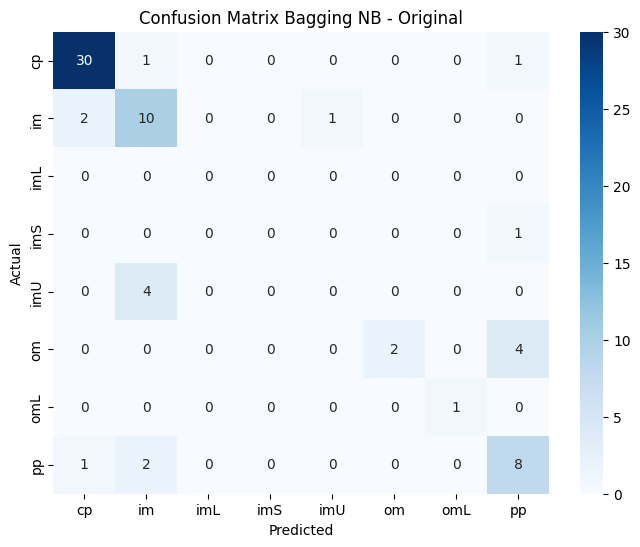

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_origin, y_origin, test_size=0.2, random_state=42
)

model = GaussianNB()

bagging = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)

prediksi = bagging.predict(X_test)
print("Akurasi:", accuracy_score(y_test, prediksi))
acc_orig_nb_bag = accuracy_score(y_test, prediksi)
print("Classification Report:\n", classification_report(y_test, prediksi, zero_division=0))

# Confusion Matrix - Bagging NB Original
cm_bagging_nb_original = confusion_matrix(y_test, prediksi)
print("\nConfusion Matrix - Bagging NB Original:")
print(cm_bagging_nb_original)
plt.figure(figsize=(8, 6))

labels = sorted(y_origin.unique())

cm_bagging_nb_original = confusion_matrix(y_test, prediksi, labels=labels)

sns.heatmap(cm_bagging_nb_original,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title('Confusion Matrix Bagging NB - Original')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### **4.1.2 BaggingClassifier Naive Bayes Pada Data Adasyn**

Akurasi: 0.8130434782608695
Classification Report:
               precision    recall  f1-score   support

          cp       0.88      0.97      0.92        31
          im       0.94      0.55      0.70        29
         imL       1.00      1.00      1.00        26
         imS       1.00      1.00      1.00        29
         imU       0.78      0.68      0.72        31
          om       1.00      0.50      0.67        36
         omL       1.00      1.00      1.00        21
          pp       0.45      0.96      0.61        27

    accuracy                           0.81       230
   macro avg       0.88      0.83      0.83       230
weighted avg       0.88      0.81      0.82       230


Confusion Matrix - Bagging NB ADASYN:
[[30  0  0  0  0  0  0  1]
 [ 3 16  0  0  6  0  0  4]
 [ 0  0 26  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0]
 [ 0  1  0  0 21  0  0  9]
 [ 0  0  0  0  0 18  0 18]
 [ 0  0  0  0  0  0 21  0]
 [ 1  0  0  0  0  0  0 26]]


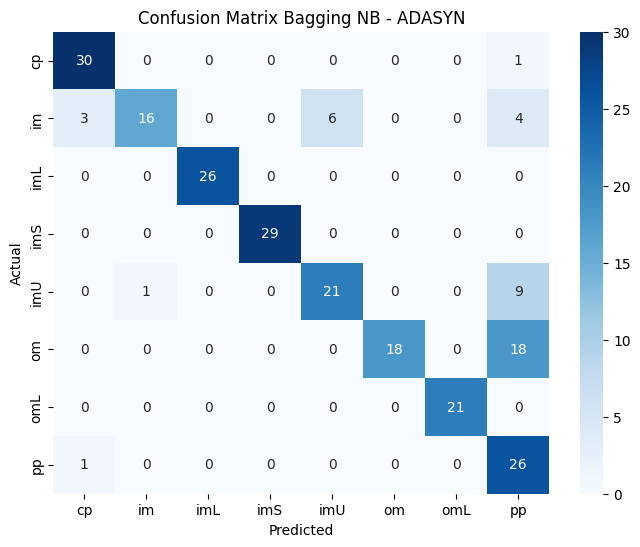

In [33]:

X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    x_adasyn, y_adasyn, test_size=0.2, random_state=42
)

model = GaussianNB()

bagging = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)
bagging.fit(X_train_adasyn, y_train_adasyn)

prediksi = bagging.predict(X_test_adasyn)
print("Akurasi:", accuracy_score(y_test_adasyn, prediksi))
acc_adasyn_nb_bag = accuracy_score(y_test_adasyn, prediksi)
print("Classification Report:\n", classification_report(y_test_adasyn, prediksi, zero_division=0))

# Confusion Matrix - Bagging NB ADASYN
cm_bagging_nb_adasyn = confusion_matrix(y_test_adasyn, prediksi)
print("\nConfusion Matrix - Bagging NB ADASYN:")
print(cm_bagging_nb_adasyn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bagging_nb_adasyn, annot=True, fmt='d', cmap='Blues',
           xticklabels=sorted(y_adasyn.unique()),
           yticklabels=sorted(y_adasyn.unique()))
plt.title('Confusion Matrix Bagging NB - ADASYN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### **4.1.3 BaggingClassifier Naive Bayes Pada Data SMOTE**

Akurasi: 0.8296943231441049
Classification Report:
               precision    recall  f1-score   support

          cp       1.00      0.97      0.98        32
          im       0.69      0.79      0.73        28
         imL       1.00      1.00      1.00        29
         imS       1.00      1.00      1.00        31
         imU       0.70      0.59      0.64        27
          om       1.00      0.28      0.43        29
         omL       0.95      1.00      0.97        19
          pp       0.62      1.00      0.76        34

    accuracy                           0.83       229
   macro avg       0.87      0.83      0.82       229
weighted avg       0.87      0.83      0.81       229


Confusion Matrix - Bagging NB SMOTE:
[[31  0  0  0  0  0  0  1]
 [ 0 22  0  0  6  0  0  0]
 [ 0  0 29  0  0  0  0  0]
 [ 0  0  0 31  0  0  0  0]
 [ 0 10  0  0 16  0  0  1]
 [ 0  0  0  0  1  8  1 19]
 [ 0  0  0  0  0  0 19  0]
 [ 0  0  0  0  0  0  0 34]]


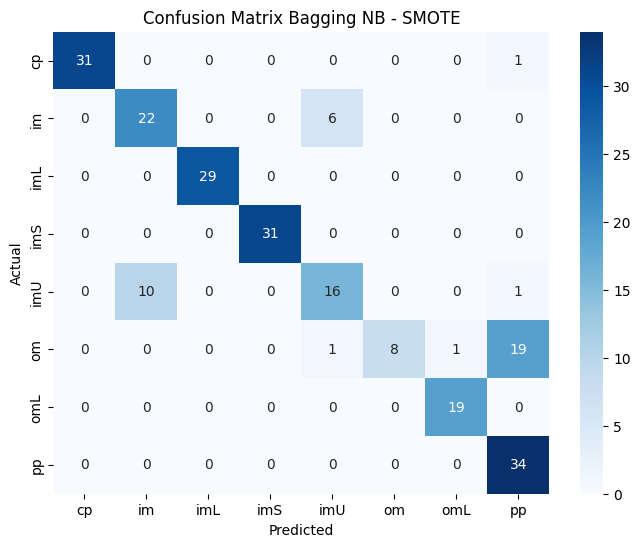

In [34]:

X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42
)

model = GaussianNB()

bagging = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)
bagging.fit(X_train_smote, y_train_smote)

prediksi = bagging.predict(X_test_smote)
print("Akurasi:", accuracy_score(y_test_smote, prediksi))
acc_smote_nb_bag = accuracy_score(y_test_smote, prediksi)
print("Classification Report:\n", classification_report(y_test_smote, prediksi, zero_division=0))

# Confusion Matrix - Bagging NB SMOTE
cm_bagging_nb_smote = confusion_matrix(y_test_smote, prediksi)
print("\nConfusion Matrix - Bagging NB SMOTE:")
print(cm_bagging_nb_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bagging_nb_smote, annot=True, fmt='d', cmap='Blues',
           xticklabels=sorted(y_smote.unique()),
           yticklabels=sorted(y_smote.unique()))
plt.title('Confusion Matrix Bagging NB - SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### **4.1.4 Perbandingan Akurasi BaggingClassifier Naive Bayes (Original vs Adisyn vs Smote)**

Akurasi Original  : 0.7500
Akurasi ADASYN    : 0.8130
Akurasi SMOTE     : 0.8297


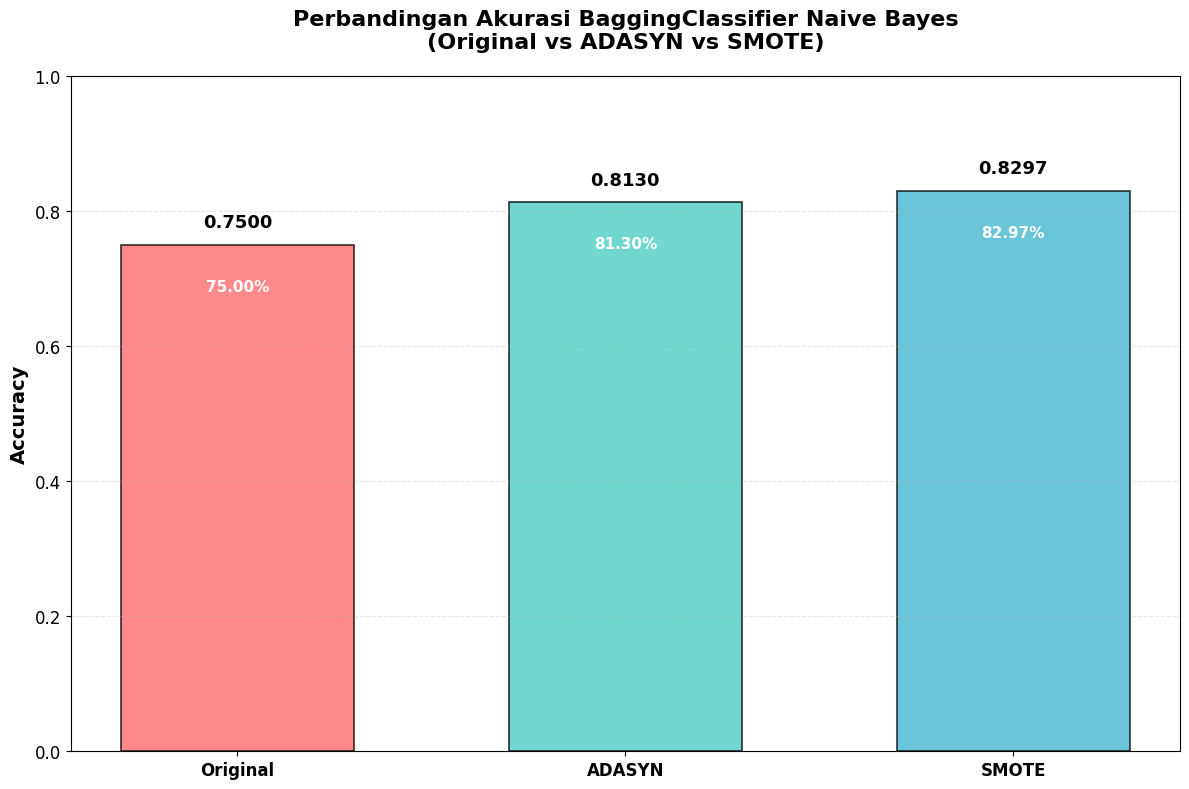

In [35]:
methods = ['Original', 'ADASYN', 'SMOTE']
accuracies = [acc_orig_nb_bag, acc_adasyn_nb_bag, acc_smote_nb_bag]

print(f"Akurasi Original  : {acc_orig_nb_bag:.4f}")
print(f"Akurasi ADASYN    : {acc_adasyn_nb_bag:.4f}")
print(f"Akurasi SMOTE     : {acc_smote_nb_bag:.4f}")

# === VISUALISASI BAR CHART ===
plt.figure(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Coral, Teal, Blue
bars = plt.bar(methods, accuracies, color=colors, width=0.6, alpha=0.8, edgecolor='black', linewidth=1.2)


plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.title('Perbandingan Akurasi BaggingClassifier Naive Bayes\n(Original vs ADASYN vs SMOTE)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12)

for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.4f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=13, color='black')
    
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05, 
            f'{acc*100:.2f}%', ha='center', va='top', 
            fontweight='bold', fontsize=11, color='white')

plt.grid(True, alpha=0.3, axis='y', linestyle='--')


plt.tight_layout()
plt.show()



### **4.2 BaggingClassifier Random Forest**

#### **4.2.1 BaggingClassifier Decision Tree Pada Data Original (Sebelum Oversampling)**

Akurasi: 0.8676470588235294
Classification Report:
               precision    recall  f1-score   support

          cp       0.91      1.00      0.96        32
          im       0.75      0.69      0.72        13
         imS       0.00      0.00      0.00         1
         imU       0.60      0.75      0.67         4
          om       1.00      1.00      1.00         6
         omL       1.00      1.00      1.00         1
          pp       0.89      0.73      0.80        11

    accuracy                           0.87        68
   macro avg       0.74      0.74      0.73        68
weighted avg       0.86      0.87      0.86        68


Confusion Matrix - Bagging DT Original:
[[32  0  0  0  0  0  0]
 [ 2  9  0  2  0  0  0]
 [ 0  0  0  0  0  0  1]
 [ 0  1  0  3  0  0  0]
 [ 0  0  0  0  6  0  0]
 [ 0  0  0  0  0  1  0]
 [ 1  2  0  0  0  0  8]]


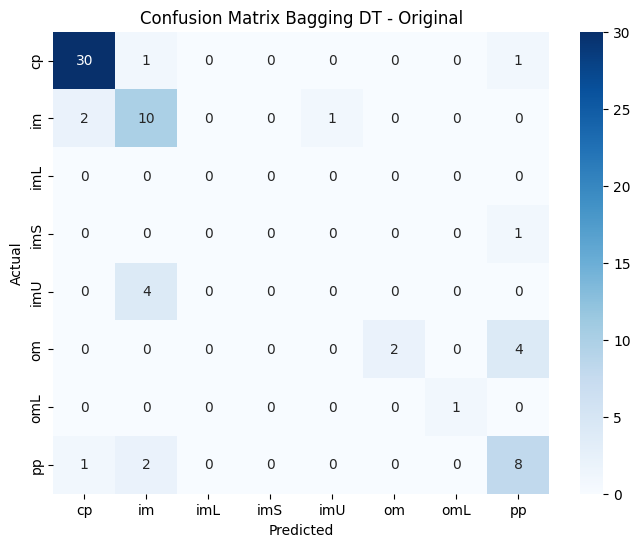

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_origin, y_origin, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()

bagging = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)

prediksi = bagging.predict(X_test)
print("Akurasi:", accuracy_score(y_test, prediksi))
acc_orig_dt_bag = accuracy_score(y_test, prediksi)
print("Classification Report:\n", classification_report(y_test, prediksi, zero_division=0))

# Confusion Matrix - Bagging DT Original
cm_bagging_dt_original = confusion_matrix(y_test, prediksi)
print("\nConfusion Matrix - Bagging DT Original:")
print(cm_bagging_dt_original)
plt.figure(figsize=(8, 6))

labels = sorted(y_origin.unique())

cm_bagging_dt_original = confusion_matrix(y_test, prediksi, labels=labels)

sns.heatmap(cm_bagging_nb_original,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title('Confusion Matrix Bagging DT - Original')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### **4.2.2 BaggingClassifier Decison Tree Pada Data Adasyn**

Akurasi: 0.9217391304347826
Classification Report:
               precision    recall  f1-score   support

          cp       0.91      0.97      0.94        31
          im       0.87      0.69      0.77        29
         imL       1.00      1.00      1.00        26
         imS       0.97      1.00      0.98        29
         imU       0.77      0.87      0.82        31
          om       0.97      0.97      0.97        36
         omL       0.95      1.00      0.98        21
          pp       0.96      0.89      0.92        27

    accuracy                           0.92       230
   macro avg       0.93      0.92      0.92       230
weighted avg       0.92      0.92      0.92       230


Confusion Matrix - Bagging DT ADASYN:
[[30  0  0  0  0  0  0  1]
 [ 1 20  0  0  8  0  0  0]
 [ 0  0 26  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0]
 [ 0  3  0  1 27  0  0  0]
 [ 0  0  0  0  0 35  1  0]
 [ 0  0  0  0  0  0 21  0]
 [ 2  0  0  0  0  1  0 24]]


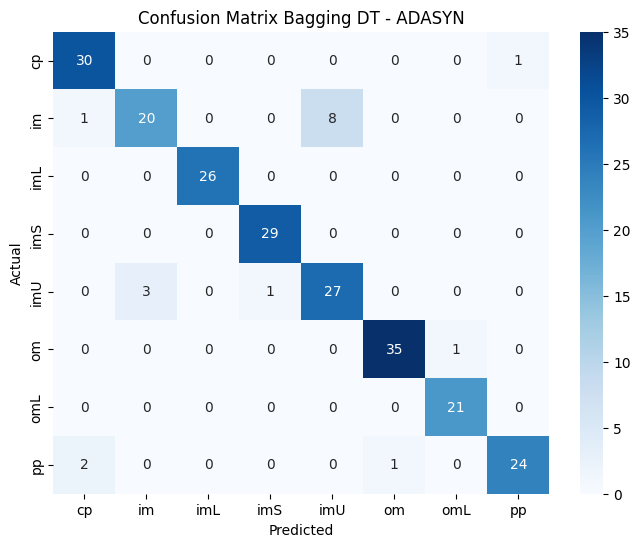

In [37]:

X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    x_adasyn, y_adasyn, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()

bagging = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)
bagging.fit(X_train_adasyn, y_train_adasyn)

prediksi = bagging.predict(X_test_adasyn)
print("Akurasi:", accuracy_score(y_test_adasyn, prediksi))
acc_adasyn_dt_bag = accuracy_score(y_test_adasyn, prediksi)
print("Classification Report:\n", classification_report(y_test_adasyn, prediksi, zero_division=0))

# Confusion Matrix - Bagging DT ADASYN
cm_bagging_dt_adasyn = confusion_matrix(y_test_adasyn, prediksi)
print("\nConfusion Matrix - Bagging DT ADASYN:")
print(cm_bagging_dt_adasyn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bagging_dt_adasyn, annot=True, fmt='d', cmap='Blues',
           xticklabels=sorted(y_adasyn.unique()),
           yticklabels=sorted(y_adasyn.unique()))
plt.title('Confusion Matrix Bagging DT - ADASYN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### **4.2.3 BaggingClassifier Decison Tree Pada Data Smote**

Akurasi: 0.9650655021834061
Classification Report:
               precision    recall  f1-score   support

          cp       0.94      1.00      0.97        32
          im       1.00      0.82      0.90        28
         imL       1.00      1.00      1.00        29
         imS       1.00      1.00      1.00        31
         imU       0.84      1.00      0.92        27
          om       1.00      0.97      0.98        29
         omL       0.95      1.00      0.97        19
          pp       1.00      0.94      0.97        34

    accuracy                           0.97       229
   macro avg       0.97      0.97      0.96       229
weighted avg       0.97      0.97      0.96       229


Confusion Matrix - Bagging DT SMOTE:
[[32  0  0  0  0  0  0  0]
 [ 0 23  0  0  5  0  0  0]
 [ 0  0 29  0  0  0  0  0]
 [ 0  0  0 31  0  0  0  0]
 [ 0  0  0  0 27  0  0  0]
 [ 0  0  0  0  0 28  1  0]
 [ 0  0  0  0  0  0 19  0]
 [ 2  0  0  0  0  0  0 32]]


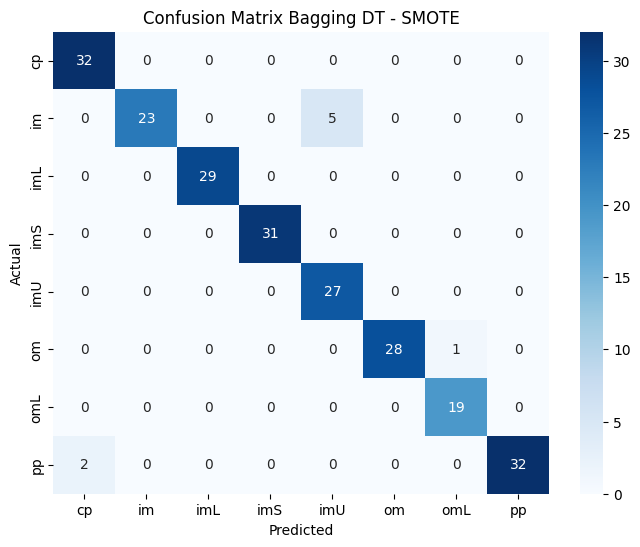

In [38]:

X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()

bagging = BaggingClassifier(estimator=model, n_estimators=100, random_state=42)
bagging.fit(X_train_smote, y_train_smote)

prediksi = bagging.predict(X_test_smote)
print("Akurasi:", accuracy_score(y_test_smote, prediksi))
acc_smote_dt_bag = accuracy_score(y_test_smote, prediksi)
print("Classification Report:\n", classification_report(y_test_smote, prediksi, zero_division=0))

# Confusion Matrix - Bagging DT SMOTE
cm_bagging_dt_smote = confusion_matrix(y_test_smote, prediksi)
print("\nConfusion Matrix - Bagging DT SMOTE:")
print(cm_bagging_dt_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bagging_dt_smote, annot=True, fmt='d', cmap='Blues',
           xticklabels=sorted(y_smote.unique()),
           yticklabels=sorted(y_smote.unique()))
plt.title('Confusion Matrix Bagging DT - SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### **4.2.4 Perbandingan Akurasi BaggingClassifier Decision Tree (Original vs Adisyn vs Smote)**

Akurasi Original  : 0.8676
Akurasi ADASYN    : 0.9217
Akurasi SMOTE     : 0.9651


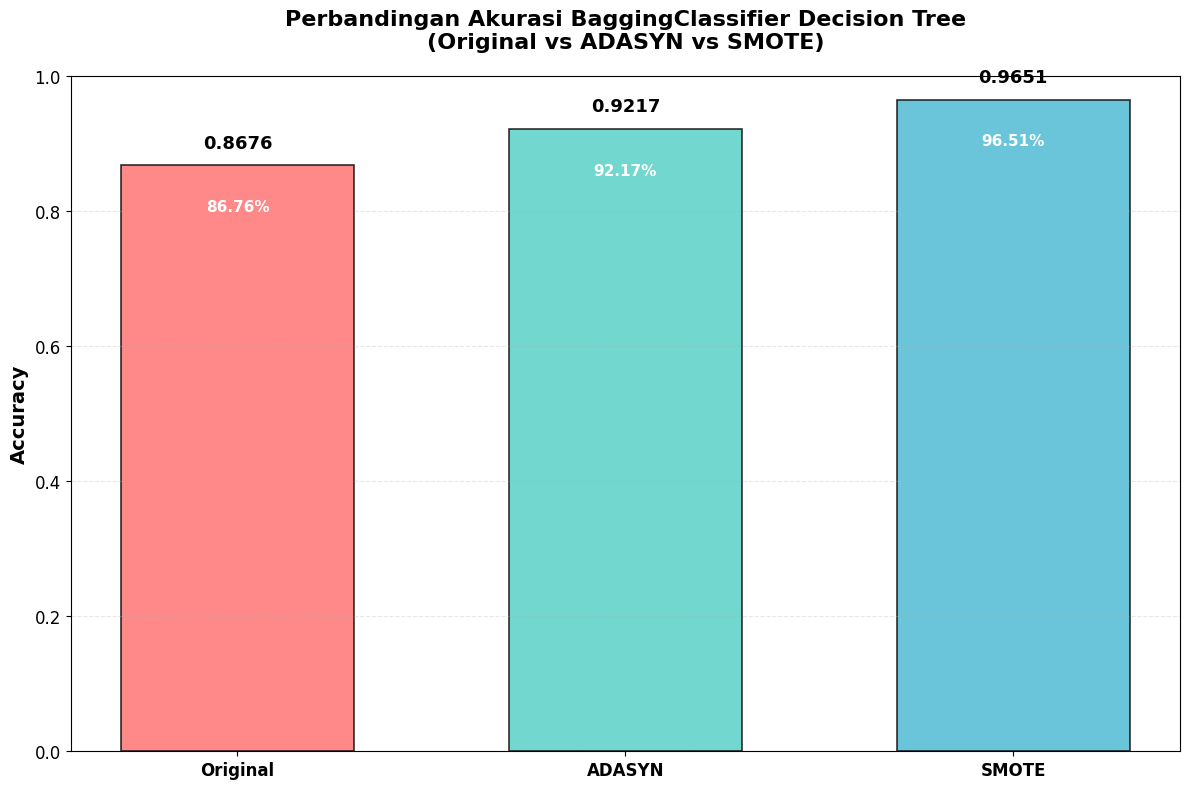

In [39]:
methods = ['Original', 'ADASYN', 'SMOTE']
accuracies = [acc_orig_dt_bag, acc_adasyn_dt_bag, acc_smote_dt_bag]

print(f"Akurasi Original  : {acc_orig_dt_bag:.4f}")
print(f"Akurasi ADASYN    : {acc_adasyn_dt_bag:.4f}")
print(f"Akurasi SMOTE     : {acc_smote_dt_bag:.4f}")

# === VISUALISASI BAR CHART ===
plt.figure(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Coral, Teal, Blue
bars = plt.bar(methods, accuracies, color=colors, width=0.6, alpha=0.8, edgecolor='black', linewidth=1.2)


plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.title('Perbandingan Akurasi BaggingClassifier Decision Tree\n(Original vs ADASYN vs SMOTE)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12)

for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{acc:.4f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=13, color='black')
    
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05, 
            f'{acc*100:.2f}%', ha='center', va='top', 
            fontweight='bold', fontsize=11, color='white')

plt.grid(True, alpha=0.3, axis='y', linestyle='--')


plt.tight_layout()
plt.show()

